# A/B testing & causal inference: analysis walk-through

**Stakeholder:** a marketing team running an ad-incrementality test. **Decision:** did the campaign cause
more visits/conversions, is the experiment trustworthy, and who should be targeted next time?
**Data:** Criteo AI Lab's public randomized incrementality benchmark (Diemert et al., 2018): 13,979,592 real
users, treatment = shown ads vs. held out, with anonymised features (privacy). A random 1,499,378-row sample
is used throughout for speed; results are cached in `artifacts/results.json`.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image
from abtest import config

res = json.loads((config.ARTIFACTS / "results.json").read_text())
res["dataset"]

{'n_sample': 1499378,
 'n_total_source': 13979592,
 'treat_ratio': 0.850325935154444,
 'nominal_treat_ratio': 0.85,
 'conversion_rate': 0.0028898649973522353,
 'visit_rate': 0.0469361295150389}

## 1. Is the experiment itself trustworthy?

Before trusting any effect estimate: does the observed treatment/control split match the intended
randomization ratio (**sample ratio mismatch**), and are pre-treatment covariates balanced between arms?

In [2]:
print("SRM chi-square p-value:", round(res["srm"]["p_value"], 3), "-> flagged:", res["srm"]["flagged"])
pd.DataFrame(res["balance"]).round(4)

SRM chi-square p-value: 0.264 -> flagged: 0.0


,feature,smd,t_p_value,flagged
0,f0,-0.0105,0.0000,False
1,f1,0.0296,0.0000,False
2,f2,-0.0069,0.0026,False
3,f3,-0.0513,0.0000,False
4,f4,0.0119,0.0000,False
5,f5,-0.0313,0.0000,False
6,f6,-0.0404,0.0000,False
7,f7,0.0204,0.0000,False
8,f8,-0.0251,0.0000,False
9,f9,0.0283,0.0000,False


No SRM issue and all 12 covariates fall inside the usual |SMD| < 0.1 convention — the randomization looks clean at this scale.

## 2. Is there a treatment effect?

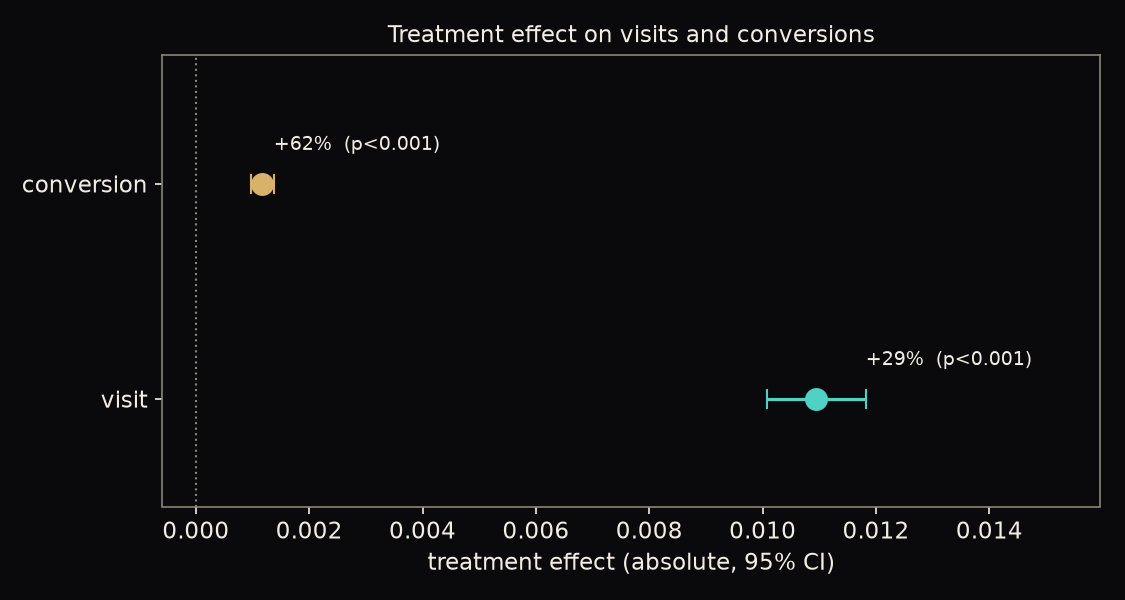

In [3]:
Image(str(config.FIGURES / "01_ate.png"))

In [4]:
pd.DataFrame(res["ate"]).T[["p_control", "p_treat", "ate", "relative_lift", "p_value"]]

,p_control,p_treat,ate,relative_lift,p_value
visit,0.037626,0.048575,0.010949,0.290984,0.0
conversion,0.001894,0.003065,0.001171,0.618552,0.0


Both outcomes show a clear, highly significant effect: **+29% relative lift in visits**, **+62% in
conversions**. The 95% CIs exclude zero by a wide margin (z > 11 for conversion). For context, a lift this
large is far above the minimum this sample size could reliably detect:

In [5]:
res["required_n_per_arm_10pct_mde"]  # users/arm needed to detect a 10% relative lift, for comparison

{'visit': 42075, 'conversion': 868622}

Detecting a 10% relative lift in conversion would need ~869k users per arm; this experiment only had 224k in
control — but the *actual* effect (62%) is so much larger that it was easily detectable anyway. A smaller,
more realistic campaign effect could easily have been missed at this control-arm size.

## 3. CUPED: shrinking the interval without changing the estimate

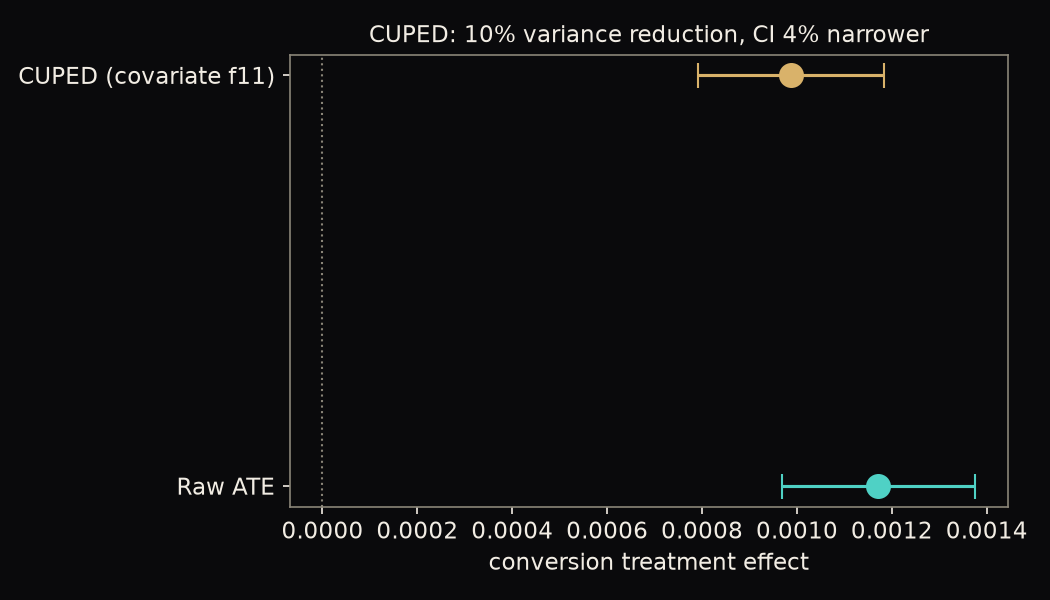

In [6]:
Image(str(config.FIGURES / "02_cuped.png"))

In [7]:
res["cuped"]

{'raw_ate': 0.0011714067163187548,
 'raw_ci': [0.00096753748652008, 0.0013752759461174296],
 'raw_se': 0.0001040168244961486,
 'cuped_ate': 0.0009875070603900483,
 'cuped_ci': [0.0007923472760413018, 0.0011826668447387947],
 'cuped_se': 9.957314822524393e-05,
 'variance_reduction': 0.10122390137294168,
 'ci_width_reduction': 0.04272074534508774,
 'covariate': 'f11'}

**Honest result: CUPED helps only modestly here** (10% variance reduction, CI ~4% narrower), because
conversion is rare (0.29%) and the best available anonymised covariate is only weakly correlated with it —
most of a rare binary outcome's variance simply isn't explainable by any one covariate. CUPED's payoff is
much bigger on continuous, high-variance metrics (revenue, session length) with a genuinely predictive
pre-period covariate; this dataset does not have one for conversion.

## 4. Who should be targeted? Uplift modeling

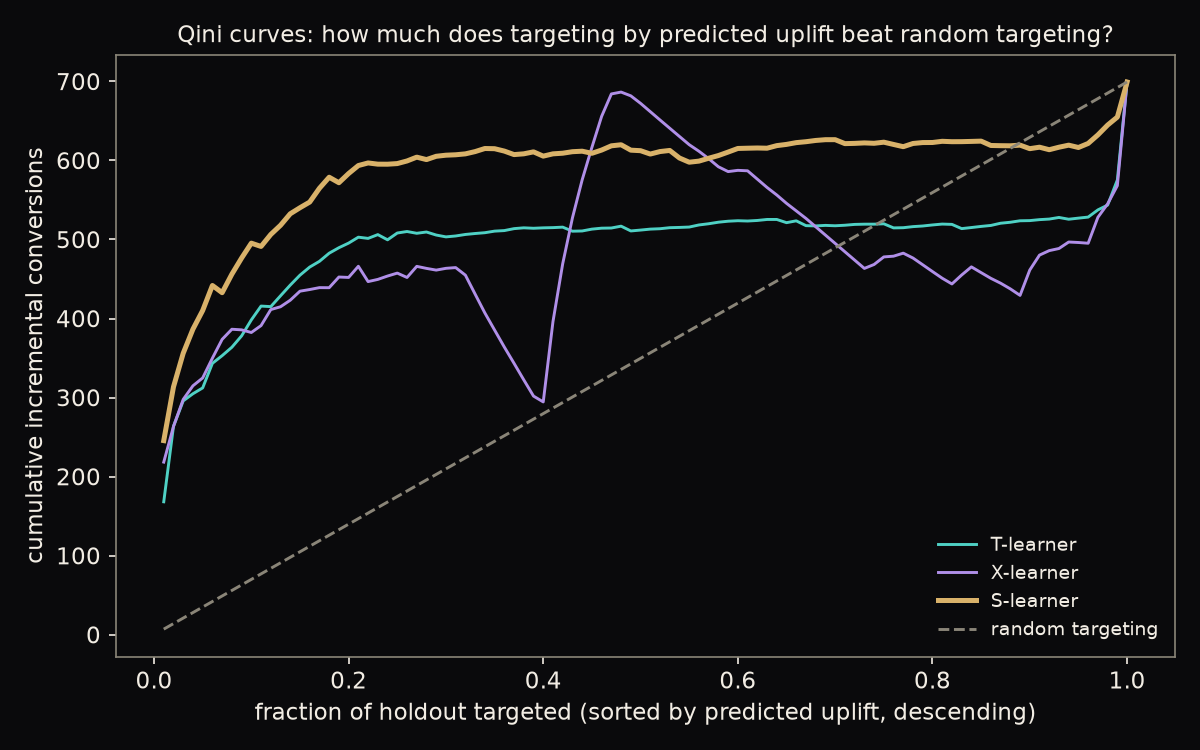

In [8]:
Image(str(config.FIGURES / "03_qini.png"))

In [9]:
res["uplift"]["auuc"]

{'T-learner': 488.8001150395246,
 'X-learner': 475.5438580014442,
 'S-learner': 582.3446860775485,
 'random': 349.5856029417681}

The **S-learner** wins on AUUC (582 vs. random's 350), ahead of the T-learner (489) and notably ahead of the
**X-learner (476)**, whose Qini curve is visibly unstable (a sharp spike-and-crash around the 40-50% mark in
the figure above) — with a modest, fairly homogeneous treatment effect and a single shared class balance
across the whole dataset, the X-learner's extra machinery (imputing individual effects, then re-regressing
them) adds variance without adding signal. Simpler was better here.

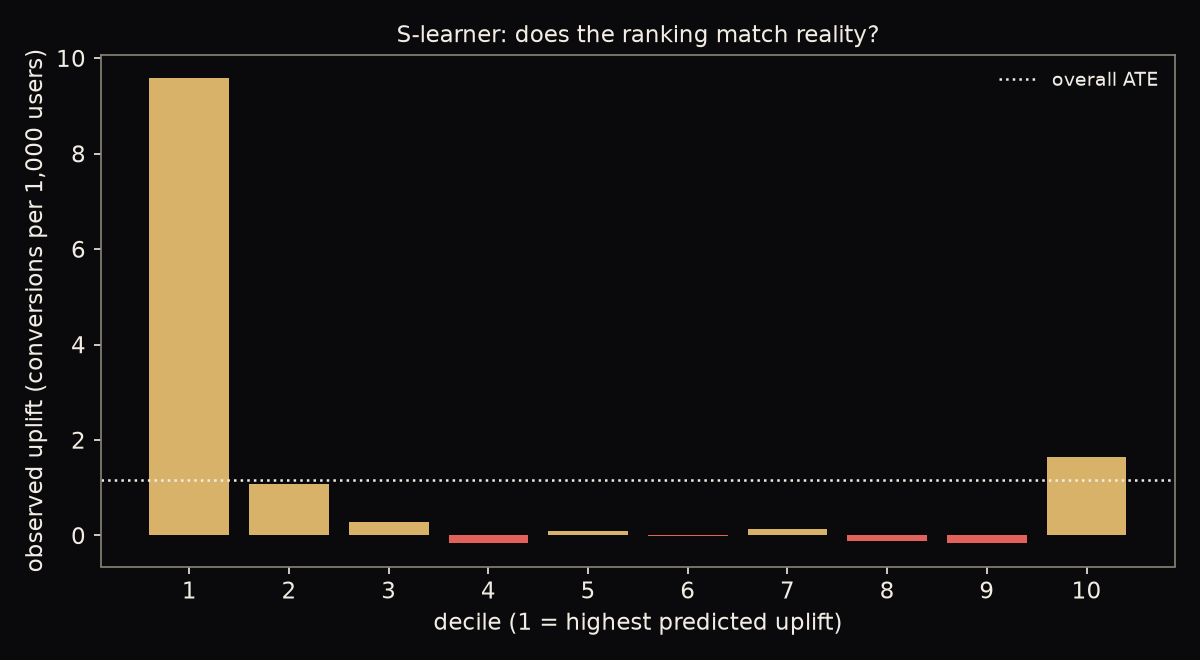

In [10]:
Image(str(config.FIGURES / "04_deciles.png"))

Ranking users by predicted uplift and slicing into deciles shows the effect concentrates almost entirely in
**decile 1** (highest predicted uplift); deciles 2-10 hover noisily around the overall ATE line because
conversion is rare (a few thousand events spread across ~60,000 users per decile — individual decile
estimates carry real sampling noise, most visible in the erratic decile 10).

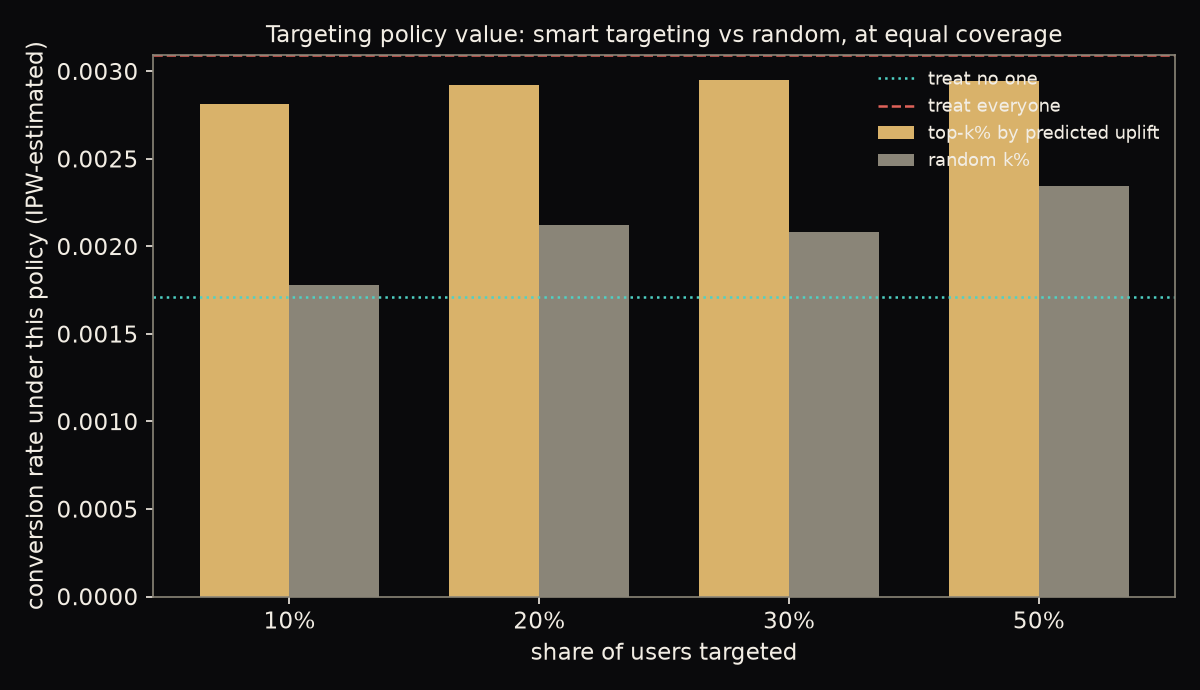

In [11]:
Image(str(config.FIGURES / "05_policy_value.png"))

In [12]:
pv = res["uplift"]["policy_values"]
pd.DataFrame({k: {"value": v["value"], "ci_lo": v["ci"][0], "ci_hi": v["ci"][1]} for k, v in pv.items()}).T.round(5)

,value,ci_lo,ci_hi
treat_all,0.00309,0.00294,0.00325
treat_none,0.00171,0.00144,0.00198
top_10pct_uplift,0.00281,0.00262,0.00301
random_10pct,0.00178,0.00153,0.00203
top_20pct_uplift,0.00292,0.00273,0.00311
random_20pct,0.00212,0.00186,0.00238
top_30pct_uplift,0.00295,0.00276,0.00313
random_30pct,0.00208,0.00184,0.00232
top_50pct_uplift,0.00294,0.00276,0.00312
random_50pct,0.00234,0.00213,0.00255


**Policy takeaway.** All targeting-policy values are estimated with an unbiased inverse-propensity-weighted
estimator on a holdout the uplift model never trained on — valid *because* the underlying treatment was truly
randomized with a known probability, not because the model is assumed correct. Targeting only the **top 10%**
by predicted uplift beats *random* 10% targeting at every coverage level tested, and captures a large share of
`treat_all`'s total value at a tenth of the targeting cost — a legitimate "spend less, capture most of the
lift" story, not a false-precision claim: see the decile chart above for how much of that gain rides on one
noisy top slice.

## 5. The peeking problem (a labelled simulation, not the Criteo data)

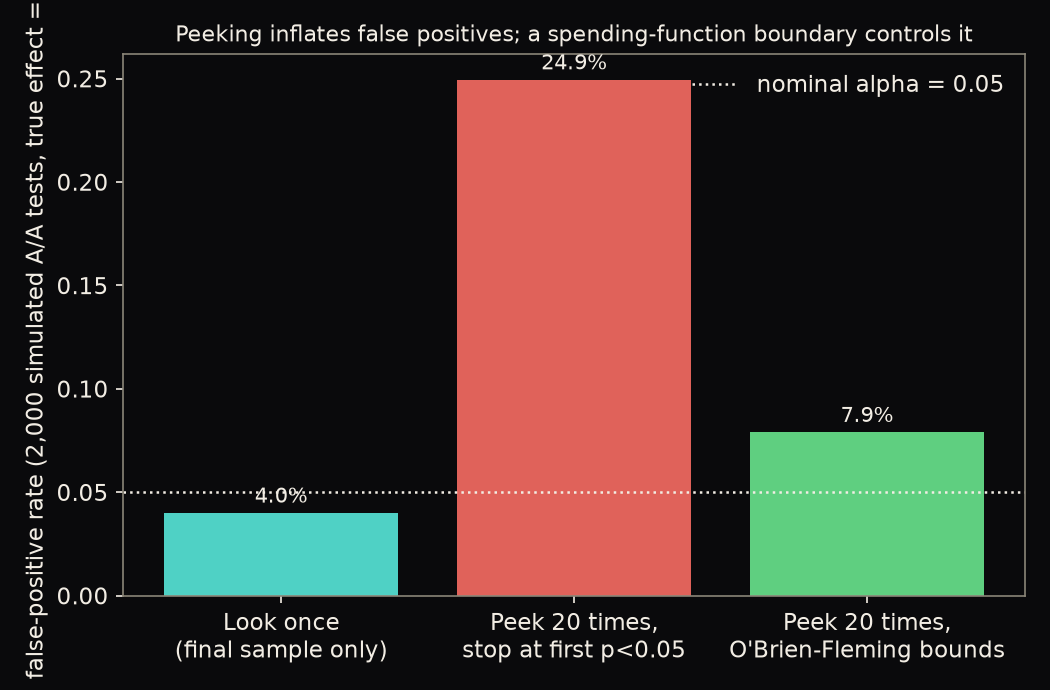

In [13]:
Image(str(config.FIGURES / "06_peeking.png"))

In [14]:
res["peeking"]

{'naive': {'n_experiments': 2000,
  'n_looks': 20,
  'nominal_alpha': 0.05,
  'false_positive_rate_final_only': 0.04,
  'false_positive_rate_with_peeking': 0.2495,
  'mean_stop_fraction': 0.2972945891783567},
 'corrected': {'n_experiments': 2000,
  'n_looks': 20,
  'nominal_alpha': 0.05,
  'false_positive_rate_corrected': 0.079}}

2,000 simulated A/A tests (both arms truly identical, so any "win" is a false positive by construction).
Looking once at a fixed final sample gives a false-positive rate close to the nominal 5%. **Peeking 20 times
and stopping at the first significant result inflates that to ~25%** — a 5x error-rate blowup from nothing
but checking the dashboard too often. An O'Brien-Fleming alpha-spending boundary (much stricter early,
relaxing toward the nominal alpha at the final look) brings it back down to ~8%, close to nominal.